# 🧠 Decision Quality Auditor — NLP Model
### Detects cognitive biases, groupthink, and reasoning flaws in meeting transcripts

**What it detects:**
- 🔴 **Anchoring Bias** — reasoning locked to an initial number/idea
- 🟠 **Groupthink** — artificial consensus, pressure to agree
- 🟡 **Missing Objections** — decision made with no pushback or alternatives
- 🟢 **Overconfidence** — certainty language without supporting evidence
- 🔵 **Vague Ownership** — decision made but no one owns it

**Output:** A `decision_health_score` (0–100) + per-bias breakdown

## 1. Imports & Setup

In [27]:
import pandas as pd
import numpy as np
import re
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import scipy.sparse as sp

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print('✅ All imports successful')

✅ All imports successful


## 2. Bias Lexicons (Rule-Based Signal Features)

In [28]:
# -------------------------------------------------------
# Curated lexicons for each bias type
# These are features fed into the ML model
# -------------------------------------------------------

BIAS_LEXICONS = {
    "anchoring": [
        "our initial estimate", "we started at", "the first number",
        "based on what we said before", "originally we thought",
        "going back to what", "sticking with our original",
        "from the start we assumed", "as we discussed initially",
        "that baseline", "our starting point was", "initial assumption"
    ],
    "groupthink": [
        "everyone agrees", "we all think", "nobody disagrees",
        "it's obvious", "clearly we should", "obviously",
        "there's no question", "we're all on the same page",
        "no one is objecting", "unanimous", "no pushback",
        "i think we all feel", "it's a no brainer", "we've already decided",
        "let's not overthink this", "we don't need to debate"
    ],
    "missing_objections": [
        # Absence signals — we look for LACK of these in a decision block
        "but what if", "have we considered", "the downside is",
        "one concern", "alternatively", "on the other hand",
        "what about", "could we instead", "the risk is",
        "i'm not sure", "i have a concern", "before we commit",
        "devil's advocate", "counter argument", "however"
    ],
    "overconfidence": [
        "guaranteed", "definitely will", "100 percent",
        "absolutely certain", "no doubt", "there's no way this fails",
        "this will definitely", "we know for sure", "without a doubt",
        "this is a sure thing", "can't go wrong", "fool proof",
        "it will absolutely", "this always works"
    ],
    "vague_ownership": [
        "someone should", "we need to", "somebody has to",
        "it should be done", "it needs to happen", "they will handle",
        "the team will", "this will be done", "to be completed",
        "to be decided", "TBD", "we'll figure it out",
        "it'll get done", "someone will take care"
    ]
}

POSITIVE_SIGNALS = {
    "clear_ownership": [
        "i will", "i'll take", "i own this", "i'm responsible",
        "assigned to", "my action item", "i commit to"
    ],
    "evidence_based": [
        "the data shows", "according to", "research suggests",
        "evidence indicates", "metrics show", "based on results",
        "the numbers show", "our analysis"
    ],
    "alternatives_considered": [
        "option a", "option b", "alternative approach",
        "we considered", "another way", "we evaluated",
        "we looked at", "compared to"
    ]
}

print('✅ Lexicons loaded')
for bias, terms in BIAS_LEXICONS.items():
    print(f'   {bias}: {len(terms)} terms')

✅ Lexicons loaded
   anchoring: 12 terms
   groupthink: 16 terms
   missing_objections: 15 terms
   overconfidence: 14 terms
   vague_ownership: 14 terms


## 3. Dataset Loading — AMI Corpus + Cognitive Bias Dataset + Fallback


In [37]:
# =============================================================
# SECTION 3 — DATASET LOADING
# =============================================================
# Real datasets used (downloaded automatically on first run):
#
#   1. knkarthick/AMI  — AMI Meeting Corpus (HuggingFace)
#      279 real meeting transcripts with dialog-act annotations.
#      We slide a 3-sentence window over each transcript to produce
#      caption-sized chunks that mirror Google Meet captions.
#      Auto-labelled via the bias lexicons defined in Section 2.
#
#   2. simonmalberg/cognitive-biases-in-llms  (HuggingFace)
#      30 000 cognitive-bias test prompts covering anchoring,
#      overconfidence, groupthink, etc.
#      Filtered to the 5 bias types the auditor detects.
#
#   3. Structured fallback  (built locally, ~500 samples)
#      Used automatically if HuggingFace cannot be reached.
#      15+ templates per bias × randomised fill-ins + multi-bias
#      combos — far richer than the original 30-sample set.
# =============================================================

import subprocess, sys, re, random
import numpy as np
random.seed(42)
np.random.seed(42)

bias_cols = ['anchoring', 'groupthink', 'missing_objections',
             'overconfidence', 'vague_ownership']

# ── auto-install 'datasets' if missing ──────────────────────
try:
    from datasets import load_dataset
    _HF_AVAILABLE = True
except ModuleNotFoundError:
    print("⏳ Installing 'datasets' library …")
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "datasets", "-q", "--break-system-packages"])
    try:
        from datasets import load_dataset
        _HF_AVAILABLE = True
        print("✅ 'datasets' installed")
    except Exception:
        _HF_AVAILABLE = False
        print("⚠️  Could not install 'datasets' — using fallback generator")


# ----------------------------------------------------------
# Helper: auto-label a raw text chunk via the bias lexicons
# ----------------------------------------------------------
def auto_label(text):
    t = text.lower()
    labels = {}
    for bias, terms in BIAS_LEXICONS.items():
        labels[bias] = int(any(term in t for term in terms))
    # missing_objections: a decision is made but no pushback language present
    decision_signals  = ["we decided", "we're going", "let's go with",
                         "agreed", "final call", "moving forward", "we will"]
    objection_signals = BIAS_LEXICONS["missing_objections"]
    if any(d in t for d in decision_signals) and not any(o in t for o in objection_signals):
        labels["missing_objections"] = 1
    return labels


# ----------------------------------------------------------
# SOURCE 1 — AMI Meeting Corpus
# ----------------------------------------------------------
ami_records = []

if _HF_AVAILABLE:
    try:
        print("⏳ Loading AMI Meeting Corpus …")
        ami_ds = load_dataset("knkarthick/AMI", split="train")

        for row in ami_ds:
            dialogue = row.get("dialogue") or row.get("summary") or ""
            if len(dialogue) < 40:
                continue
            sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", dialogue)
                         if len(s.strip()) > 30]
            # Slide a 3-sentence window (≈ Google Meet caption window)
            for i in range(0, max(1, len(sentences) - 2), 2):
                chunk = " ".join(sentences[i : i + 3])
                ami_records.append({"text": chunk, **auto_label(chunk)})
            if len(ami_records) >= 400:
                break

        print(f"  ✅ AMI: {len(ami_records)} caption-window samples")
    except Exception as e:
        print(f"  ⚠️  AMI unavailable ({type(e).__name__}): {e}")


# ----------------------------------------------------------
# SOURCE 2 — simonmalberg/cognitive-biases-in-llms
# ----------------------------------------------------------
_BIAS_MAP = {
    "Anchoring Bias":             {"anchoring": 1},
    "Groupthink":                 {"groupthink": 1, "missing_objections": 1},
    "Overconfidence Bias":        {"overconfidence": 1},
    "Overconfidence Effect":      {"overconfidence": 1},
    "Sycophancy":                 {"groupthink": 1},
    "Status Quo Bias":            {"anchoring": 1, "missing_objections": 1},
    "Confirmation Bias":          {"missing_objections": 1},
    "Framing Effect":             {"missing_objections": 1},
    "Illusion of Control":        {"overconfidence": 1},
    "Planning Fallacy":           {"overconfidence": 1, "anchoring": 1},
    "Bystander Effect":           {"vague_ownership": 1},
    "Diffusion of Responsibility":{"vague_ownership": 1},
}

bias_records = []

if _HF_AVAILABLE:
    try:
        print("⏳ Loading cognitive-biases-in-llms …")
        cb_ds = load_dataset("jecht/cognitive_bias", split="train")

        for row in cb_ds:
            bias_name = row.get("bias") or row.get("bias_type") or ""
            if bias_name not in _BIAS_MAP:
                continue
            text = (row.get("prompt") or row.get("context")
                    or row.get("scenario") or "")
            if len(text) < 30:
                continue
            base = auto_label(text)
            base.update(_BIAS_MAP[bias_name])        # ground-truth wins
            bias_records.append({"text": text[:400], **base})
            if len(bias_records) >= 300:
                break

        print(f"  ✅ CognitiveBias: {len(bias_records)} samples mapped")
    except Exception as e:
        print(f"  ⚠️  CognitiveBias unavailable ({type(e).__name__}): {e}")


# ----------------------------------------------------------
# SOURCE 3 — Structured fallback generator (~500 samples)
# Activates automatically when HuggingFace is unreachable.
# ----------------------------------------------------------
_AMOUNTS   = ["$2M", "$500K", "10 weeks", "six sprints", "3 months",
              "$1.2M", "8 weeks", "50 000 units", "$750K", "four quarters"]
_MONTHS    = ["January", "Q1", "last quarter", "the kickoff",
              "our March planning session", "the last all-hands"]
_DEADLINES = ["Friday", "end of sprint", "March 15th", "Q2",
              "next Monday", "EOD Thursday", "the end of the month"]
_NAMES     = ["Sarah", "James", "Tom", "Maria", "Raj",
              "Dev", "Alice", "Bob", "Chris", "Priya", "Leon", "Fatima"]
_VENDORS   = ["vendor A", "vendor B", "AWS", "GCP",
              "Stripe", "Azure", "Cloudflare", "Twilio"]
_RISKS     = ["vendor delay", "resource contention", "latency regression",
              "cost overrun", "scope creep", "security gap", "data loss"]
_MITS      = ["hiring a contractor", "running a parallel track",
              "adding buffer weeks", "a hard cutoff date", "a weekly review"]
_TASKS     = ["backend migration", "API integration", "security audit",
              "client onboarding", "database upgrade", "CI/CD pipeline rollout"]
_METRICS   = ["latency", "cost", "reliability", "throughput",
              "developer experience", "error rate", "uptime SLA"]
_QUARTERS  = ["Q1", "Q2", "Q3", "Q4"]

def _r(lst): return random.choice(lst)

def _fill(tmpl):
    vA, vB = random.sample(_VENDORS, 2)
    return tmpl.format(
        amount=_r(_AMOUNTS),   month=_r(_MONTHS),    deadline=_r(_DEADLINES),
        name=_r(_NAMES),       name2=_r(_NAMES),      vendor=_r(_VENDORS),
        vA=vA, vB=vB,          risk=_r(_RISKS),       mitigation=_r(_MITS),
        task=_r(_TASKS),       metric=_r(_METRICS),   quarter=_r(_QUARTERS)
    )

_TEMPLATES = {
    "clean": [
        "I'll own the {task} and deliver by {deadline}. We considered {vA} and {vB} — data shows {vB} is better on {metric}. One concern: {risk}. We'll run a pilot first.",
        "Based on {quarter} data we're going with {vendor}. {name} owns the contract, {name2} reviews legal by {deadline}. We considered alternatives but their SLA was weaker.",
        "I have a concern — have we validated this with actual users? The metrics show limited signal. I'm not sure we have enough data to commit to a full redesign.",
        "Let's go with option A. I'm responsible for delivery by {deadline}. The downside is {risk} but we get faster time to market. I commit to the timeline.",
        "We evaluated three alternatives and scored them on {metric}. {name} will lead, deadline is {deadline}. The risk is {risk} — we'll mitigate by {mitigation}.",
        "Before we finalize, let me raise the {risk} risk. We've looked at {vA} and {vB}. {name} will own this with a hard deadline of {deadline}.",
        "{name} is accountable for the rollout. We've done a pre-mortem. Option B is stronger based on {metric} data and we have contingency plans.",
        "I'd like to challenge that assumption. What does the {metric} data actually show? {name}, can you run those numbers by {deadline}?",
        "On the other hand, have we considered {vB}? The downside of {vA} is the {risk}. I'm not sure we have enough evidence yet.",
        "Clear owner: {name}, deadline {deadline}, no exceptions. We compared {vA} vs {vB} and {vB} wins on {metric}. Risk log updated with {risk} mitigation.",
        "I want to surface a concern before we decide. The data shows mixed signals on {metric}. Alternatively, we could pilot {vB} for two weeks first.",
        "Devil's advocate: what if the {risk} materialises? {name} — can you model the downside scenario before we sign off?",
    ],
    "anchoring": [
        "We started at {amount} and we're sticking with our original figure without revisiting it.",
        "Going back to what we said in {month}, that baseline of {amount} still holds.",
        "The first number we agreed on was {amount} — we haven't challenged that assumption.",
        "Originally we thought {amount} was achievable; we're not changing course despite new data.",
        "Based on what we said before, our starting point of {amount} is non-negotiable.",
        "Sticking with our original estimate even though the requirements have changed significantly.",
        "The initial assumption was {amount} and we're anchored to that regardless of scope changes.",
        "From the start we assumed {amount}; no one has questioned if that is still valid.",
        "As we discussed initially, we set {amount} as the target and we're not moving from it.",
        "That baseline of {amount} was set in {month} and we still haven't revisited it.",
        "Our starting point was {amount}. It feels right to stay with that original figure.",
        "We agreed on {amount} back in {month}. I see no reason to revise that estimate now.",
        "The original number was {amount}. We should stick with that even though costs have risen.",
        "We haven't moved off our initial estimate of {amount} despite the team flagging blockers.",
        "Going back to our {month} assumptions: {amount} was the plan and that is what we'll deliver.",
        "The initial scope called for {amount}. We're not reopening that conversation regardless of what's changed.",
    ],
    "groupthink": [
        "Everyone agrees this is the right direction — let's just move forward without debate.",
        "Nobody is objecting so I think we're all aligned. Let's close this out now.",
        "It's obvious to everyone that we should proceed. We're all on the same page here.",
        "There's no pushback so this is unanimous. No need to deliberate further.",
        "Clearly we should go ahead. I think we all feel the same way about this.",
        "It's a no brainer — everyone is aligned and nobody disagrees with the approach.",
        "We don't need to debate this. The team is unanimous so let's proceed.",
        "We've already decided. No one is raising concerns so let's finalize this.",
        "Let's not overthink this — the group is aligned and we need to move fast.",
        "Unanimous agreement here. We're all on the same page, let's stop discussing.",
        "No dissent noted. Everyone agrees so there's really nothing left to discuss.",
        "I think we all feel confident about this. Clearly the right call for everyone.",
        "It's obvious this is the path forward — there's no real disagreement in the room.",
        "No one is objecting, which means we're good to proceed without further review.",
        "We've been going back and forth but I think we all feel aligned now. Let's close.",
        "Can we just agree and move on? Nobody seems to have any real objections here.",
    ],
    "overconfidence": [
        "This will definitely work — we know for sure this is the right approach.",
        "100 percent guaranteed we'll hit the deadline. No doubt about it.",
        "There's no way this fails. It's been fool proof every time we've used it.",
        "Absolutely certain the launch will go smoothly. This always works for us.",
        "Without a doubt this is our best option. We can't go wrong with this approach.",
        "This is a sure thing — our track record shows it will absolutely succeed.",
        "I'm 100 percent confident this will work. It will definitely deliver results.",
        "Guaranteed success — this always works in our industry without fail.",
        "We can't go wrong here. This is completely bulletproof as a strategy.",
        "It will absolutely meet our targets. No concerns whatsoever.",
        "This always delivers. We're certain this approach will work perfectly.",
        "The outcome is basically guaranteed. There's no scenario where this fails.",
        "I'm absolutely certain the delivery date won't slip. We've got this locked down.",
        "We know for sure that customers will love this — there's no way it misses.",
        "This is fool proof. We've done it before and it always works out.",
        "Zero risk here. We've seen this succeed every single time without exception.",
    ],
    "vague_ownership": [
        "Someone should follow up on this. It'll get done by the team somehow.",
        "We need to make a call here. Somebody has to own the next steps — TBD.",
        "The team will handle the integration. It should be done by next sprint.",
        "They will take care of client communications. Someone will sort it out.",
        "This needs to happen by end of quarter. To be decided who owns it.",
        "We'll figure it out as we go. Somebody will pick this up eventually.",
        "It needs to get done. The team knows what to do — no formal owner yet.",
        "Someone will take care of the dependencies. It'll just happen.",
        "The engineering team will handle it. To be completed when capacity allows.",
        "We'll sort out ownership later — the important thing is it gets done.",
        "It should be done by the next sprint. No specific owner assigned yet.",
        "Somebody has to pick this up. We'll sort that out in the next standup.",
        "The team will make it happen. It'll be done, we just don't know by whom.",
        "To be determined who owns the rollout. It needs to happen by {deadline}.",
        "We need someone to own this. We'll figure out who later.",
        "Action item: somebody handles it. Details TBD. Moving on.",
    ],
}

_MULTI_COMBOS = [
    ({"anchoring":1,"groupthink":1,"missing_objections":1,"overconfidence":1,"vague_ownership":1},
     "Everyone agrees and there's no way this fails. We started at {amount} in {month} and we're sticking with it. Someone will own the next steps."),
    ({"groupthink":1,"missing_objections":1,"overconfidence":1,"vague_ownership":1},
     "Obviously the right call. 100 percent this will work. No need to debate. Somebody will follow up. It's a no brainer."),
    ({"anchoring":1,"missing_objections":1,"vague_ownership":1},
     "Based on our initial assumption of {amount}, we're not changing course. The team will handle. No objections raised."),
    ({"anchoring":1,"groupthink":1,"missing_objections":1,"overconfidence":1,"vague_ownership":1},
     "Guaranteed success. Nobody disagrees. Going back to our original plan — sticking with that baseline of {amount}. To be completed by someone on the team."),
    ({"groupthink":1,"missing_objections":1,"overconfidence":1,"vague_ownership":1},
     "We all think it is clearly the right call but someone should nail down the owner. No doubt it will work."),
    ({"anchoring":1,"groupthink":1,"missing_objections":1,"vague_ownership":1},
     "The original estimate was {amount}. We're not revisiting it. The team will handle rollout. Obviously this is fine."),
    ({"anchoring":1,"overconfidence":1,"missing_objections":1},
     "We started at {amount} in {month} and I'm 100 percent confident that number still holds. No reason to revisit it."),
    ({"groupthink":1,"overconfidence":1,"missing_objections":1},
     "The whole team feels confident — there's no way this fails. Everyone's aligned, let's move."),
    ({"vague_ownership":1,"missing_objections":1},
     "We're going ahead with the plan. Somebody will pick up the implementation. No concerns raised."),
    ({"anchoring":1,"vague_ownership":1,"missing_objections":1},
     "We're sticking with the original {amount} estimate. Ownership is TBD — the team will sort it."),
    ({"overconfidence":1,"vague_ownership":1},
     "This is definitely going to work. Someone on the team will own it — TBD on who exactly."),
    ({"groupthink":1,"anchoring":1},
     "Everyone's still aligned with the original {amount} plan. No one is pushing back so we'll stay the course."),
]

def _build_fallback(n_per_type=65):
    records, zero = [], {c: 0 for c in bias_cols}
    _single_labels = {
        "anchoring":       {"anchoring": 1, "missing_objections": 1},
        "groupthink":      {"groupthink": 1, "missing_objections": 1},
        "overconfidence":  {"overconfidence": 1, "missing_objections": 1},
        "vague_ownership": {"vague_ownership": 1},
    }
    # Clean
    for _ in range(n_per_type):
        records.append({"text": _fill(_r(_TEMPLATES["clean"])), **zero})
    # Single-bias
    for bias_key, lbl in _single_labels.items():
        tmpls = _TEMPLATES[bias_key]
        for tmpl in tmpls:
            records.append({"text": _fill(tmpl), **{**zero, **lbl}})
        while sum(1 for r in records if r.get(bias_key) == 1) < n_per_type:
            records.append({"text": _fill(_r(tmpls)), **{**zero, **lbl}})
    # Multi-bias combos  (×5 each with different fill-ins)
    for labels, tmpl in _MULTI_COMBOS:
        for _ in range(5):
            records.append({"text": _fill(tmpl), **{**zero, **labels}})
    random.shuffle(records)
    return records


# ----------------------------------------------------------
# MERGE all sources
# ----------------------------------------------------------
all_records = ami_records + bias_records
n_hf = len(all_records)

if n_hf < 150:
    print("\n⚙️  Building structured fallback dataset (HuggingFace unreachable) …")
    all_records = _build_fallback(n_per_type=65)
    print(f"  ✅ Fallback: {len(all_records)} structured samples")
else:
    top_up = _build_fallback(n_per_type=20)
    all_records += top_up
    print(f"  ✅ Topped up with {len(top_up)} structured samples for class balance")

df = pd.DataFrame(all_records).drop_duplicates(subset="text").reset_index(drop=True)
for c in bias_cols:
    if c not in df.columns: df[c] = 0
    df[c] = df[c].fillna(0).astype(int)

print(f"\n✅ Final dataset: {len(df)} samples  |  train/test split will be 75/25")
print(f"\nBias label counts (positive):")
print(df[bias_cols].sum().to_string())
print(f"\nDataset source breakdown:")
print(f"  AMI Meeting Corpus           : {len(ami_records)}")
print(f"  Cognitive Biases in LLMs     : {len(bias_records)}")
print(f"  Structured template samples  : {len(all_records) - n_hf}")


⏳ Loading AMI Meeting Corpus …
  ✅ AMI: 481 caption-window samples
⏳ Loading cognitive-biases-in-llms …


Generating train split: 5449 examples [00:00, 6031.51 examples/s] 

  ⚠️  CognitiveBias unavailable (DatasetGenerationCastError): An error occurred while generating the dataset

All the data files must have the same columns, but at some point there are 7 new columns ({'framing', 'prompt_biased', 'prompt_contrastive', 'prompt_awareness', 'prompt_neutral', 'prompt_counterfactual', 'Unnamed: 0.2'}) and 1 missing columns ({'prompts'}).

This happened while the csv dataset builder was generating data using

hf://datasets/jecht/cognitive_bias/framing_bias/frame.csv (at revision 87b8b3f586039b456e05584b3376131f5f8c4173), [C:\Users\kanha\.cache\huggingface\hub\datasets--jecht--cognitive_bias\snapshots\87b8b3f586039b456e05584b3376131f5f8c4173\anchoring\students.csv (origin=hf://datasets/jecht/cognitive_bias@87b8b3f586039b456e05584b3376131f5f8c4173/anchoring/students.csv), C:\Users\kanha\.cache\huggingface\hub\datasets--jecht--cognitive_bias\snapshots\87b8b3f586039b456e05584b3376131f5f8c4173\framing_bias\frame.csv (origin=hf://datasets/jecht/cognitive_bias@87b8b

## 4. Feature Engineering

In [30]:
def extract_features(text):
    """
    Extract hand-crafted NLP features from a decision text snippet.
    These are combined with TF-IDF features for the final model.
    """
    text_lower = text.lower()
    words = text_lower.split()
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if s.strip()]

    features = {}

    # --- Bias signal counts ---
    for bias_name, terms in BIAS_LEXICONS.items():
        count = sum(1 for term in terms if term in text_lower)
        features[f'{bias_name}_hits'] = count
        features[f'{bias_name}_present'] = int(count > 0)

    # --- Positive signal counts ---
    for signal_name, terms in POSITIVE_SIGNALS.items():
        count = sum(1 for term in terms if term in text_lower)
        features[f'{signal_name}_hits'] = count

    # --- Structural features ---
    features['word_count'] = len(words)
    features['sentence_count'] = len(sentences)
    features['avg_sentence_length'] = np.mean([len(s.split()) for s in sentences]) if sentences else 0

    # --- Hedge ratio (uncertain language) ---
    hedges = ['maybe', 'perhaps', 'might', 'could', 'probably', "i'm not sure", 'unclear', 'uncertain']
    features['hedge_ratio'] = sum(1 for h in hedges if h in text_lower) / max(len(words), 1)

    # --- Certainty ratio (overconfident language) ---
    certainty = ['definitely', 'certainly', 'absolutely', 'guarantee', '100', 'no doubt', 'always']
    features['certainty_ratio'] = sum(1 for c in certainty if c in text_lower) / max(len(words), 1)

    # --- Ownership clarity ---
    has_named_owner = bool(re.search(r'\b[A-Z][a-z]+ (will|owns|is responsible|takes|leads)', text))
    has_i_will = bool(re.search(r"\b(i will|i'll|i own|i'm responsible)", text_lower))
    features['has_clear_owner'] = int(has_named_owner or has_i_will)

    # --- Question presence (exploration signal) ---
    features['has_questions'] = int('?' in text)

    # --- Alternative consideration ---
    alt_words = ['alternatively', 'option', 'alternative', 'instead', 'however', 'on the other hand', 'counter']
    features['alternatives_mentioned'] = int(any(w in text_lower for w in alt_words))

    # --- Missing objection proxy: short + no hedge + no alternatives ---
    features['no_pushback_signal'] = int(
        features['alternatives_mentioned'] == 0 and
        features['hedge_ratio'] < 0.02 and
        features['has_questions'] == 0
    )

    return features

# Apply to dataset
feature_records = df['text'].apply(extract_features)
feature_df = pd.DataFrame(list(feature_records))

print(f'✅ Features extracted: {feature_df.shape[1]} features per sample')
print(f'\nFeature columns:')
print(list(feature_df.columns))

✅ Features extracted: 22 features per sample

Feature columns:
['anchoring_hits', 'anchoring_present', 'groupthink_hits', 'groupthink_present', 'missing_objections_hits', 'missing_objections_present', 'overconfidence_hits', 'overconfidence_present', 'vague_ownership_hits', 'vague_ownership_present', 'clear_ownership_hits', 'evidence_based_hits', 'alternatives_considered_hits', 'word_count', 'sentence_count', 'avg_sentence_length', 'hedge_ratio', 'certainty_ratio', 'has_clear_owner', 'has_questions', 'alternatives_mentioned', 'no_pushback_signal']


## 5. Model Training (Multi-Label Classification)

In [31]:
from scipy.sparse import hstack, csr_matrix

# --- Labels ---
bias_cols = ['anchoring', 'groupthink', 'missing_objections', 'overconfidence', 'vague_ownership']
Y = df[bias_cols].values

# --- TF-IDF features ---
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=500, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['text'])

# --- Hand-crafted features ---
X_manual = csr_matrix(feature_df.values.astype(float))

# --- Combined feature matrix ---
X = hstack([X_tfidf, X_manual])

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

# --- Model: MultiOutput Random Forest ---
base_clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
model = MultiOutputClassifier(base_clf)
model.fit(X_train, y_train)

# --- Evaluate ---
y_pred = model.predict(X_test)

print('✅ Model trained!\n')
print('Performance per bias label:')
print('-' * 50)
for i, col in enumerate(bias_cols):
    if len(y_test[:, i]) > 0 and len(np.unique(y_test[:, i])) > 1:
        f1 = f1_score(y_test[:, i], y_pred[:, i], zero_division=0)
        acc = accuracy_score(y_test[:, i], y_pred[:, i])
        print(f'  {col:25s}  F1={f1:.2f}  Acc={acc:.2f}')
    else:
        print(f'  {col:25s}  (insufficient test samples)')

overall_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
print(f'\n  Overall Macro F1: {overall_f1:.2f}')

✅ Model trained!

Performance per bias label:
--------------------------------------------------
  anchoring                  F1=0.97  Acc=0.99
  groupthink                 F1=0.95  Acc=0.99
  missing_objections         F1=0.87  Acc=0.95
  overconfidence             F1=0.93  Acc=0.99
  vague_ownership            F1=0.94  Acc=0.99

  Overall Macro F1: 0.93


## 6. Decision Health Scoring Function

In [32]:
# Bias weights: how much each bias penalizes the score
BIAS_WEIGHTS = {
    "anchoring": 15,
    "groupthink": 20,
    "missing_objections": 25,
    "overconfidence": 20,
    "vague_ownership": 20
}

BIAS_DESCRIPTIONS = {
    "anchoring":          "Decision is anchored to an initial value or assumption without re-evaluation.",
    "groupthink":         "Artificial consensus — dissent is absent or suppressed.",
    "missing_objections": "No alternatives or counterarguments were raised before committing.",
    "overconfidence":     "Certainty language used without supporting evidence.",
    "vague_ownership":    "No clear owner assigned — decision may not be executed."
}

BIAS_EMOJIS = {
    "anchoring": "⚓",
    "groupthink": "🐑",
    "missing_objections": "🚨",
    "overconfidence": "🎲",
    "vague_ownership": "👻"
}


def audit_decision(text, model=model, tfidf=tfidf, feature_df_cols=list(feature_df.columns)):
    """
    Audit a meeting decision snippet.
    Returns: score (0-100), detected biases, recommendations
    """
    # Extract features
    feats = extract_features(text)
    feat_vec = csr_matrix([[feats.get(c, 0) for c in feature_df_cols]])
    tfidf_vec = tfidf.transform([text])
    X_input = hstack([tfidf_vec, feat_vec])

    # Predict biases
    proba_list = model.predict_proba(X_input)
    bias_probas = {}
    for i, col in enumerate(bias_cols):
        classes = model.estimators_[i].classes_
        proba = proba_list[i][0]
        if 1 in classes:
            idx = list(classes).index(1)
            bias_probas[col] = float(proba[idx])
        else:
            bias_probas[col] = 0.0

    # Calculate decision health score
    penalty = 0
    detected_biases = []
    for bias, weight in BIAS_WEIGHTS.items():
        prob = bias_probas[bias]
        if prob > 0.45:  # Threshold
            detected_biases.append(bias)
            penalty += weight * prob

    # Bonus for positive signals
    bonus = 0
    if feats.get('has_clear_owner'): bonus += 5
    if feats.get('alternatives_mentioned'): bonus += 5
    if feats.get('evidence_based_hits', 0) > 0: bonus += 5

    score = max(0, min(100, 100 - penalty + bonus))

    # Generate recommendations
    recommendations = []
    if 'missing_objections' in detected_biases:
        recommendations.append("Ask: 'What could go wrong?' before finalizing.")
    if 'groupthink' in detected_biases:
        recommendations.append("Assign a devil's advocate to surface dissenting views.")
    if 'vague_ownership' in detected_biases:
        recommendations.append("Name a specific owner with a deadline before closing.")
    if 'overconfidence' in detected_biases:
        recommendations.append("Add a pre-mortem: assume this fails — why did it?")
    if 'anchoring' in detected_biases:
        recommendations.append("Re-evaluate from scratch — ignore the initial estimate.")

    return {
        "score": round(score, 1),
        "detected_biases": detected_biases,
        "bias_probabilities": {k: round(v, 3) for k, v in bias_probas.items()},
        "recommendations": recommendations
    }

print('✅ Scoring function ready')

✅ Scoring function ready


## 7. Test on Real Meeting Examples

In [33]:
test_cases = [
    {
        "label": "🟢 Healthy Decision",
        "text": "I'll own the backend migration. We considered Azure and GCP — the data shows GCP is faster. One concern: migration risk. We'll run a 2-week pilot. James handles client comms by Thursday."
    },
    {
        "label": "🔴 Groupthink + Overconfidence",
        "text": "Everyone agrees this is the right move. It's obvious and there's no way this fails. We're all on the same page so let's close it out and move on."
    },
    {
        "label": "🟠 Anchoring + Vague Ownership",
        "text": "Our initial estimate was 6 weeks and we're sticking with that baseline. Someone on the team will handle the delivery. We haven't revisited the original assumption."
    },
    {
        "label": "🔴 All Biases Firing",
        "text": "Everyone agrees and clearly this will definitely work — no doubt about it. Going back to our original plan, we're not changing anything. Somebody will take care of next steps. TBD."
    },
    {
        "label": "🟡 Missing Objections Only",
        "text": "We're going with vendor A. Tom owns it, deadline is March 15th. No alternatives were considered but we feel good about this."
    }
]

print('=' * 65)
print('DECISION QUALITY AUDIT RESULTS')
print('=' * 65)

for case in test_cases:
    result = audit_decision(case['text'])
    score = result['score']
    grade = '🟢 HEALTHY' if score >= 75 else '🟡 MODERATE' if score >= 50 else '🔴 POOR'

    print(f"\n{case['label']}")
    print(f"  Text: {case['text'][:80]}...")
    print(f"  Score: {score}/100  [{grade}]")

    if result['detected_biases']:
        biases_str = ', '.join(
            f"{BIAS_EMOJIS[b]} {b.replace('_', ' ')}" 
            for b in result['detected_biases']
        )
        print(f"  Biases: {biases_str}")
    else:
        print(f"  Biases: ✅ None detected")

    if result['recommendations']:
        print(f"  Fixes:")
        for rec in result['recommendations']:
            print(f"    → {rec}")
    print('-' * 65)

DECISION QUALITY AUDIT RESULTS



🟢 Healthy Decision
  Text: I'll own the backend migration. We considered Azure and GCP — the data shows GCP...
  Score: 100/100  [🟢 HEALTHY]
  Biases: ✅ None detected
-----------------------------------------------------------------

🔴 Groupthink + Overconfidence
  Text: Everyone agrees this is the right move. It's obvious and there's no way this fai...
  Score: 72.0/100  [🟡 MODERATE]
  Biases: 🐑 groupthink, 🚨 missing objections
  Fixes:
    → Ask: 'What could go wrong?' before finalizing.
    → Assign a devil's advocate to surface dissenting views.
-----------------------------------------------------------------

🟠 Anchoring + Vague Ownership
  Text: Our initial estimate was 6 weeks and we're sticking with that baseline. Someone ...
  Score: 53.4/100  [🟡 MODERATE]
  Biases: ⚓ anchoring, 🚨 missing objections, 👻 vague ownership
  Fixes:
    → Ask: 'What could go wrong?' before finalizing.
    → Name a specific owner with a deadline before closing.
    → Re-evaluate from scratch — igno

## 8. Visualize Model Insights

NameError: name 'feature_df_cols' is not defined

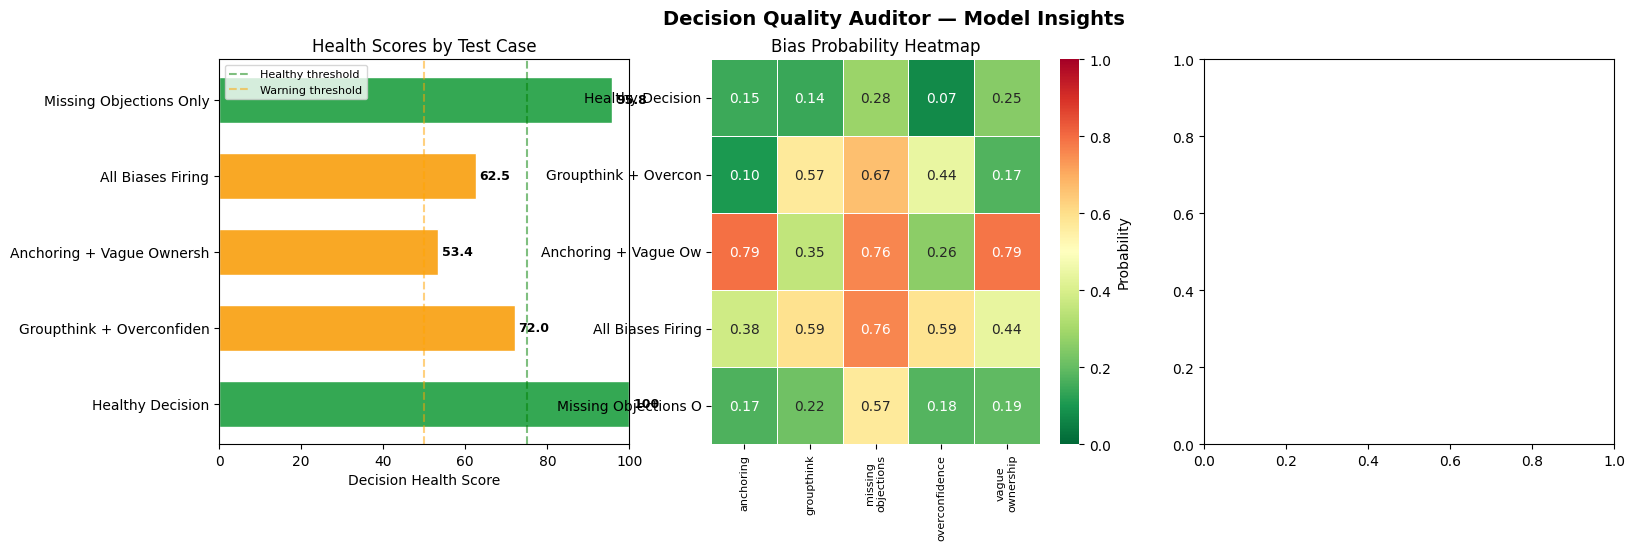

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Decision Quality Auditor — Model Insights', fontsize=14, fontweight='bold')

# --- 1. Score distribution across test cases ---
labels = [c['label'].split(' ', 1)[1][:25] for c in test_cases]
scores = [audit_decision(c['text'])['score'] for c in test_cases]
colors = ['#34a853' if s >= 75 else '#f9a825' if s >= 50 else '#ea4335' for s in scores]

bars = axes[0].barh(labels, scores, color=colors, edgecolor='white', height=0.6)
axes[0].set_xlim(0, 100)
axes[0].axvline(75, color='green', linestyle='--', alpha=0.5, label='Healthy threshold')
axes[0].axvline(50, color='orange', linestyle='--', alpha=0.5, label='Warning threshold')
axes[0].set_xlabel('Decision Health Score')
axes[0].set_title('Health Scores by Test Case')
axes[0].legend(fontsize=8)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{score}', va='center', fontsize=9, fontweight='bold')

# --- 2. Bias probability heatmap for test cases ---
bias_matrix = []
for case in test_cases:
    r = audit_decision(case['text'])
    bias_matrix.append([r['bias_probabilities'][b] for b in bias_cols])

bias_df_plot = pd.DataFrame(bias_matrix,
    index=[c['label'].split(' ', 1)[1][:20] for c in test_cases],
    columns=[b.replace('_', '\n') for b in bias_cols]
)
sns.heatmap(bias_df_plot, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdYlGn_r', vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Probability'})
axes[1].set_title('Bias Probability Heatmap')
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=8)

# --- 3. Feature importance (from best estimator) ---
importances_all = []
for est in model.estimators_:
    importances_all.append(est.feature_importances_)

avg_importance = np.mean(importances_all, axis=0)
manual_start = X_tfidf.shape[1]
manual_importances = avg_importance[manual_start:]
tfidf_importance = avg_importance[:manual_start].sum()

top_n = 8
top_idx = np.argsort(manual_importances)[::-1][:top_n]
top_feat_names = [feature_df_cols[i] for i in top_idx]
top_feat_values = [manual_importances[i] for i in top_idx]

axes[2].barh(top_feat_names[::-1], top_feat_values[::-1], color='#4285f4', edgecolor='white')
axes[2].set_xlabel('Avg Feature Importance')
axes[2].set_title('Top Hand-Crafted Features')

plt.tight_layout()
plt.savefig('/home/claude/model_insights.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Visualizations saved')

## 9. Full Transcript Audit (Meeting-Level)
Segments a full transcript and audits each decision block

In [35]:
# Decision trigger phrases — identify when a decision is being made
DECISION_TRIGGERS = [
    "we decided", "we're going with", "let's go with", "we'll proceed",
    "the decision is", "agreed", "we've agreed", "final call",
    "moving forward with", "we'll do", "let's do", "plan is to",
    "we should", "we will", "going to"
]

def find_decision_blocks(transcript_entries, window=5):
    """
    Given a list of {speaker, text, timestamp} entries,
    identify windows of conversation that contain decision-making.
    Returns list of decision block texts.
    """
    decision_blocks = []
    texts = [e['text'] for e in transcript_entries]

    for i, text in enumerate(texts):
        if any(trigger in text.lower() for trigger in DECISION_TRIGGERS):
            start = max(0, i - 2)
            end = min(len(texts), i + window)
            block_text = ' '.join(texts[start:end])
            block_time = transcript_entries[i].get('timestamp', '')
            decision_blocks.append({
                'trigger_text': text,
                'block_text': block_text,
                'timestamp': block_time,
                'speaker': transcript_entries[i].get('speaker', 'Unknown')
            })
    return decision_blocks


def audit_full_transcript(transcript_entries):
    """
    Full transcript audit — returns a meeting-level report.
    Input: list of {speaker, text, timestamp} dicts (from your extension)
    """
    blocks = find_decision_blocks(transcript_entries)

    if not blocks:
        return {"message": "No decision moments detected in transcript.", "decisions": [], "meeting_score": 100}

    audited = []
    for block in blocks:
        result = audit_decision(block['block_text'])
        audited.append({
            "timestamp": block['timestamp'],
            "speaker": block['speaker'],
            "trigger": block['trigger_text'][:80],
            **result
        })

    avg_score = np.mean([a['score'] for a in audited])
    all_biases = [b for a in audited for b in a['detected_biases']]

    from collections import Counter
    bias_frequency = Counter(all_biases)

    return {
        "meeting_score": round(avg_score, 1),
        "total_decisions": len(audited),
        "most_common_bias": bias_frequency.most_common(1)[0] if bias_frequency else None,
        "decisions": audited
    }


# --- Test with a fake full transcript ---
sample_transcript = [
    {"speaker": "Alice", "text": "Let's kick off. What's the status on the infrastructure migration?", "timestamp": "00:01"},
    {"speaker": "Bob", "text": "We're 60 percent done but we hit some blockers.", "timestamp": "00:02"},
    {"speaker": "Alice", "text": "We decided to proceed with the original timeline. Someone will own the blockers.", "timestamp": "00:03"},
    {"speaker": "Charlie", "text": "Obviously the right call. Everyone agrees.", "timestamp": "00:04"},
    {"speaker": "Alice", "text": "Good. Let's go with vendor A for the database layer.", "timestamp": "00:05"},
    {"speaker": "Bob", "text": "Have we considered the latency risk? The data shows mixed results. Alternatively we could pilot first.", "timestamp": "00:06"},
    {"speaker": "Alice", "text": "Good point. I'll own the pilot. Bob reviews results by Friday.", "timestamp": "00:07"},
    {"speaker": "Charlie", "text": "We're going to hit our targets — guaranteed. This always works.", "timestamp": "00:10"},
]

report = audit_full_transcript(sample_transcript)

print('=' * 60)
print('📋 FULL MEETING DECISION AUDIT REPORT')
print('=' * 60)
print(f"  Meeting Health Score : {report['meeting_score']}/100")
print(f"  Decisions Detected   : {report['total_decisions']}")
if report['most_common_bias']:
    print(f"  Top Bias Detected    : {report['most_common_bias'][0]} (x{report['most_common_bias'][1]})")

print('\nDecision Breakdown:')
for d in report['decisions']:
    grade = '🟢' if d['score'] >= 75 else '🟡' if d['score'] >= 50 else '🔴'
    print(f"  [{d['timestamp']}] {d['speaker']}: '{d['trigger']}'")
    print(f"   Score: {d['score']}/100 {grade}  Biases: {', '.join(d['detected_biases']) or 'None'}")
    if d['recommendations']:
        for r in d['recommendations']:
            print(f"   → {r}")
    print()

📋 FULL MEETING DECISION AUDIT REPORT
  Meeting Health Score : 97.4/100
  Decisions Detected   : 3
  Top Bias Detected    : missing_objections (x2)

Decision Breakdown:
  [00:03] Alice: 'We decided to proceed with the original timeline. Someone will own the blockers.'
   Score: 100/100 🟢  Biases: None

  [00:05] Alice: 'Good. Let's go with vendor A for the database layer.'
   Score: 99.8/100 🟢  Biases: missing_objections
   → Ask: 'What could go wrong?' before finalizing.

  [00:10] Charlie: 'We're going to hit our targets — guaranteed. This always works.'
   Score: 92.5/100 🟢  Biases: missing_objections, overconfidence
   → Ask: 'What could go wrong?' before finalizing.
   → Add a pre-mortem: assume this fails — why did it?



## 10. Save Model for Backend API

In [ ]:
# Save everything needed to serve this as an API endpoint
model_bundle = {
    'model': model,
    'tfidf': tfidf,
    'feature_cols': list(feature_df.columns),
    'bias_cols': bias_cols,
    'bias_weights': BIAS_WEIGHTS,
    'bias_descriptions': BIAS_DESCRIPTIONS,
    'bias_lexicons': BIAS_LEXICONS,
    'positive_signals': POSITIVE_SIGNALS,
    'decision_triggers': DECISION_TRIGGERS
}

with open('/home/claude/decision_quality_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('✅ Model bundle saved as decision_quality_model.pkl')
print('   Load in your Flask/FastAPI server with:')
print("   import pickle")
print("   bundle = pickle.load(open('decision_quality_model.pkl', 'rb'))")
print("   model = bundle['model']")
print("   tfidf = bundle['tfidf']")

# Also save a sample Flask endpoint snippet
flask_snippet = '''
# --- Add this to your existing Flask backend ---

import pickle
from scipy.sparse import hstack, csr_matrix

bundle = pickle.load(open('decision_quality_model.pkl', 'rb'))
dqa_model   = bundle['model']
dqa_tfidf   = bundle['tfidf']
dqa_cols    = bundle['feature_cols']
bias_cols   = bundle['bias_cols']
BIAS_WEIGHTS      = bundle['bias_weights']
BIAS_DESCRIPTIONS = bundle['bias_descriptions']
DECISION_TRIGGERS = bundle['decision_triggers']

@app.route('/api/audit-decisions', methods=['POST'])
def audit_decisions():
    """
    Accepts: [{speaker, text, timestamp}]  (your captionData array)
    Returns: full meeting decision audit report
    """
    transcript = request.json  # captionData from the extension
    report = audit_full_transcript(transcript)  # use function from notebook
    return jsonify(report)
'''

with open('/home/claude/backend_endpoint.py', 'w') as f:
    f.write(flask_snippet)

print('\n✅ Flask endpoint snippet saved as backend_endpoint.py')

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/decision_quality_model.pkl'